In [9]:
from pathlib import Path
import os

import networkx as nx

In [10]:
#path = Path(os.environ["DATADIR"]) / "orqa" / "socrata" / "nyc" / "candidates_discovery" / "matches_graph.gml"
path = Path(r"C:\Users\39377\Documents\GitHub\orqa\src\subgraph.gml")
path.exists()

True

In [11]:
G = nx.read_gml(path)

In [5]:
G.is_directed(), nx.is_connected(nx.to_undirected(G))

(True, True)

In [6]:
len([(node, degree) for node, degree in G.out_degree() if degree == 0])

1

In [7]:
u, v, data = next(iter(G.edges(data=True)))
print(f"Edge keys: {list(data.keys())}")

StopIteration: 

In [8]:
import random

node = random.choice(list(G.nodes()))
print(f"=== Node: {node} ===")
print(f"Degree: {G.degree(node)} (in: {G.in_degree(node)}, out: {G.out_degree(node)})")
print()

out_edges = list(G.out_edges(node, data=True))
in_edges = list(G.in_edges(node, data=True))

print(f"=== {len(out_edges)} outgoing edges ===")
for u, v, data in out_edges:
    task = data.get('task', 'N/A')
    print(task)
    metrics = data.get('metrics', 'N/A')
    overlap = metrics.get('overlap_ratio', 'N/A')
    macro = metrics.get('sm_macro_avg', 'N/A')
    micro = metrics.get('sm_micro_avg', 'N/A')
    print(f"  [{task}] {u} -> {v} | overlap={overlap} macro={macro} micro={micro}")

print(f"\n=== {len(in_edges)} incoming edges ===")
for u, v, data in in_edges:
    task = data.get('task', 'N/A')
    print(task)
    metrics = data.get('metrics', 'N/A')
    overlap = metrics.get('overlap_ratio', 'N/A')
    macro = metrics.get('sm_macro_avg', 'N/A')
    micro = metrics.get('sm_micro_avg', 'N/A')
    print(f"  [{task}] {u} -> {v} | overlap={overlap} macro={macro} micro={micro}")

=== Node: ipkp-snf6 ===
Degree: 0 (in: 0, out: 0)

=== 0 outgoing edges ===

=== 0 incoming edges ===


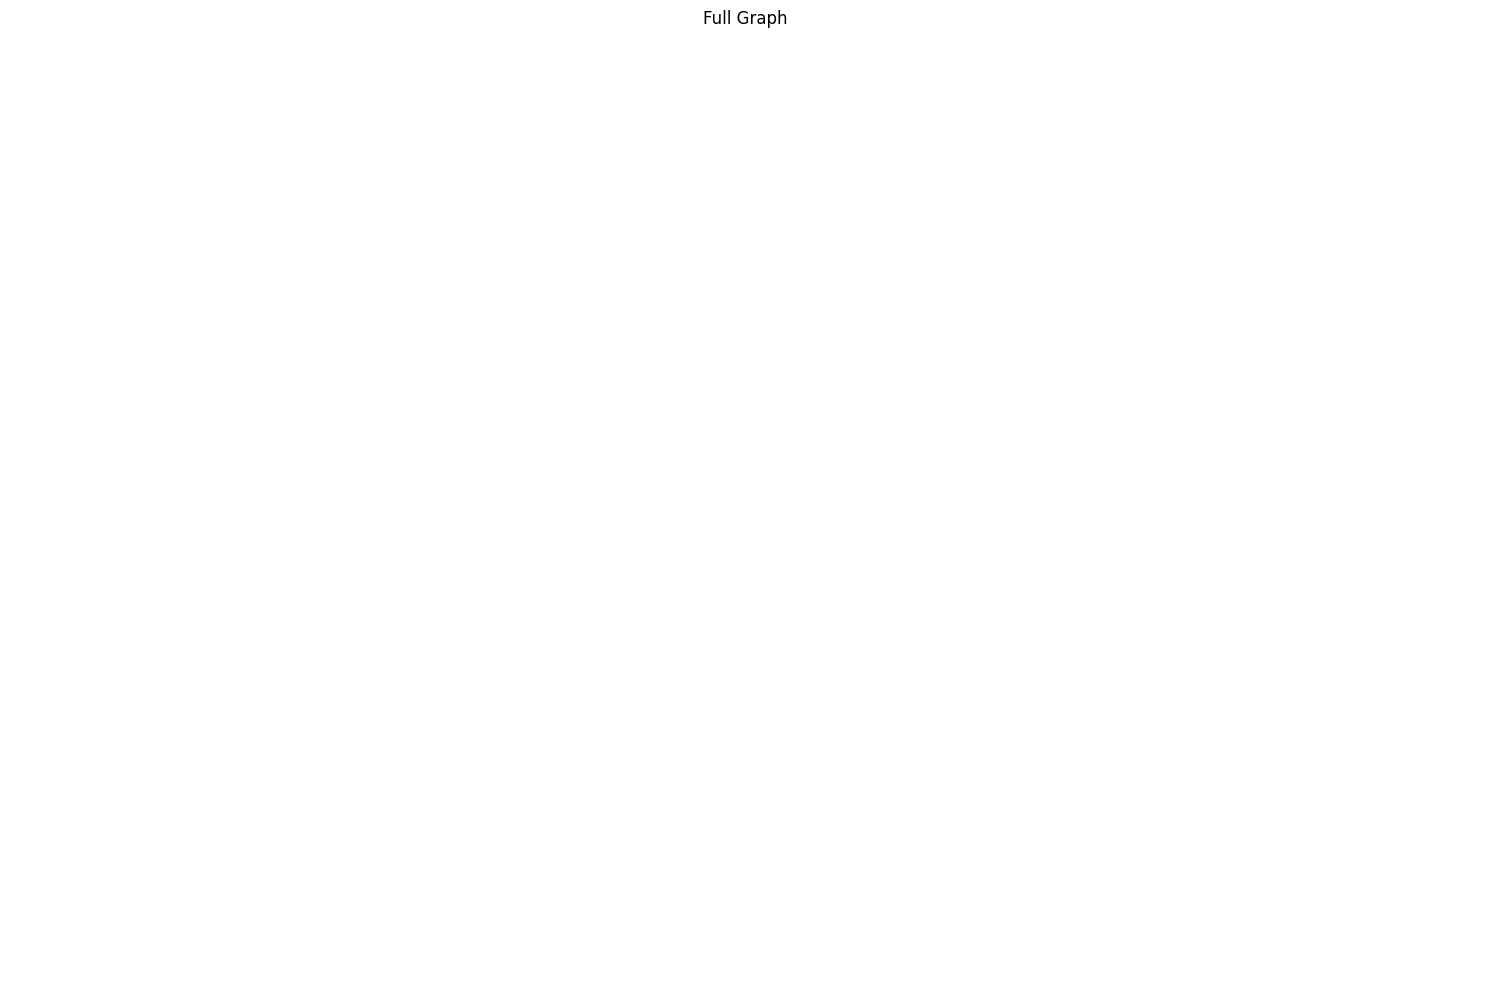

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 10))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G, pos,
    with_labels=True,
    node_size=500,
    node_color="steelblue",
    font_size=7,
    arrows=True,
    ax=ax
)

edge_labels = {(u, v): f"{d.get('overlap_ratio', 'N/A')}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, ax=ax)

ax.set_title("Full Graph")
plt.tight_layout()
plt.show()

In [ ]:
OVERLAP_THRESHOLD = 50
MACRO_THRESHOLD = 0.3
MICRO_THRESHOLD = 0.3

filtered = nx.MultiDiGraph()
for u, v, key, data in G.edges(data=True, keys=True):
    metrics = data.get("metrics", {})
    
    if not isinstance(metrics, dict) or not metrics:
        print(f"filtered out the edge of {u,v} with metrics:\n{metrics}")
        continue
    
    overlap = metrics.get("overlap_ratio", -1)
    macro = metrics.get("sm_macro_avg", -1)
    micro = metrics.get("sm_micro_avg", -1)
    
    if overlap >= OVERLAP_THRESHOLD and macro >= MACRO_THRESHOLD and micro >= MICRO_THRESHOLD:
        filtered.add_edge(u, v, key=key, **data)

fig, ax = plt.subplots(figsize=(15, 10))
pos = nx.spring_layout(filtered, seed=42)

nx.draw(
    filtered, pos,
    with_labels=True,
    node_size=500,
    node_color="coral",
    font_size=7,
    arrows=True,
    ax=ax
)

edge_labels = {
    (u, v): (
        f"ov={d.get('metrics', {}).get('overlap_ratio', 'N/A')} "
        f"ma={d.get('metrics', {}).get('sm_macro_avg', 'N/A')} "
        f"mi={d.get('metrics', {}).get('sm_micro_avg', 'N/A')}"
    )
    for u, v, d in filtered.edges(data=True)
}
nx.draw_networkx_edge_labels(filtered, pos, edge_labels=edge_labels, font_size=6, ax=ax)

ax.set_title(
    f"Filtered Graph (overlap>={OVERLAP_THRESHOLD}, macro>={MACRO_THRESHOLD}, micro>={MICRO_THRESHOLD}) — "
    f"{filtered.number_of_nodes()} nodes, {filtered.number_of_edges()} edges"
)
plt.tight_layout()
plt.show()